In [1]:
import re
import time
from urllib.parse import urljoin

import pandas as pd
import requests
from bs4 import BeautifulSoup

BASE = "https://www.fsc.go.kr"

# 금융위원회 정책일반
LIST_URL = "https://www.fsc.go.kr/po010101"

headers = {
    "User-Agent": "Mozilla/5.0"
}

rows = []

for page in range(1, 101):

    params = {
        "curPage": page,
        "srchBeginDt": "",
        "srchEndDt": "",
        "srchKey": "",
        "srchText": ""
    }

    r = requests.get(
        LIST_URL,
        params=params,
        headers=headers,
        timeout=30
    )

    r.raise_for_status()

    soup = BeautifulSoup(r.text, "html.parser")

    # 상세 페이지 링크
    links = soup.select("a[href*='/po010101/']")

    page_count = 0

    for a in links:

        href = a.get("href", "")

        # /po010101/12345 형태만
        m = re.search(r"/po010101/(\d+)", href)

        if not m:
            continue

        title = a.get_text(" ", strip=True)

        if not title:
            continue

        rows.append({
            "doc_id": m.group(1),
            "title": title,
            "url": urljoin(BASE, href)
        })

        page_count += 1

    print(
        f"{page}/100 | "
        f"page={page_count} | "
        f"total={len(rows)}"
    )

    time.sleep(0.15)


df_list = (
    pd.DataFrame(rows)
    .drop_duplicates("doc_id")
    .reset_index(drop=True)
)

print("수집:", len(df_list))
display(df_list.head())

1/100 | page=10 | total=10
2/100 | page=10 | total=20
3/100 | page=10 | total=30
4/100 | page=10 | total=40
5/100 | page=10 | total=50
6/100 | page=10 | total=60
7/100 | page=10 | total=70
8/100 | page=10 | total=80
9/100 | page=10 | total=90
10/100 | page=10 | total=100
11/100 | page=10 | total=110
12/100 | page=10 | total=120
13/100 | page=10 | total=130
14/100 | page=10 | total=140
15/100 | page=10 | total=150
16/100 | page=10 | total=160
17/100 | page=10 | total=170
18/100 | page=10 | total=180
19/100 | page=10 | total=190
20/100 | page=10 | total=200
21/100 | page=10 | total=210
22/100 | page=10 | total=220
23/100 | page=10 | total=230
24/100 | page=10 | total=240
25/100 | page=10 | total=250
26/100 | page=10 | total=260
27/100 | page=10 | total=270
28/100 | page=10 | total=280
29/100 | page=10 | total=290
30/100 | page=10 | total=300
31/100 | page=10 | total=310
32/100 | page=10 | total=320
33/100 | page=10 | total=330
34/100 | page=10 | total=340
35/100 | page=10 | total=350
36/

,doc_id,title,url
0,87585,“AI 시대 국민의 일상과 생업을 잇는 마이데이터 발전방안을 추진합니다.“,https://www.fsc.go.kr/po010101/87585?srchCtgry...
1,87572,"보험사기 가담자의 보험모집시장 진입을 차단하여 보험계약자 보호를 강화하고, 보험산업...",https://www.fsc.go.kr/po010101/87572?srchCtgry...
2,87571,보이스피싱 범죄조직 핵심 가담자 효과적 검거를 위한 사법협조자 형벌감면제도가 도입...,https://www.fsc.go.kr/po010101/87571?srchCtgry...
3,87570,"합병가액 산정방식을 개정하여 합병의 공정성을 제고하고, 주가 누르기 유인도전면 차단...",https://www.fsc.go.kr/po010101/87570?srchCtgry...
4,87569,"기술의 시간에 금융을 맞추는 새로운 시도, 초장기기술투자펀드가 개시됩니다.",https://www.fsc.go.kr/po010101/87569?srchCtgry...


In [4]:
details = []

for i, row in df_list.iterrows():

    try:
        r = requests.get(
            row["url"],
            headers=headers,
            timeout=30
        )
        r.raise_for_status()

        soup = BeautifulSoup(r.text, "html.parser")

        # 날짜
        text_all = soup.get_text(" ", strip=True)

        date_match = re.search(
            r"(20\d{2})[.\-/년]\s*(\d{1,2})[.\-/월]\s*(\d{1,2})",
            text_all
        )

        date = None
        if date_match:
            y, m, d = date_match.groups()
            date = f"{y}-{int(m):02d}-{int(d):02d}"

        # 본문
        content = ""

        for selector in [
            ".view_cont",
            ".view-content",
            ".board_view",
            ".board-view",
            ".bbs_view",
            ".content",
            ".cont"
        ]:
            node = soup.select_one(selector)

            if node:
                candidate = node.get_text(" ", strip=True)

                if len(candidate) > len(content):
                    content = candidate

        details.append({
            "doc_id": row["doc_id"],
            "date": date,
            "content": content
        })

    except Exception as e:
        print("ERROR:", row["doc_id"], e)

        details.append({
            "doc_id": row["doc_id"],
            "date": None,
            "content": ""
        })

    if (i + 1) % 50 == 0:
        print(f"{i+1}/{len(df_list)}")


# 결과 결합
df_detail = pd.DataFrame(details)

df_list = df_list.merge(
    df_detail,
    on="doc_id",
    how="left"
)

df_list["date"] = pd.to_datetime(
    df_list["date"],
    errors="coerce"
)

df_list["year"] = df_list["date"].dt.year

df_list["analysis_text"] = (
    df_list["title"].fillna("") + " " +
    df_list["content"].fillna("")
).str.strip()

print("\n완료")
print(df_list.shape)

display(df_list.head())

50/1000
100/1000
150/1000
200/1000
250/1000
300/1000
350/1000
400/1000
450/1000
500/1000
550/1000
600/1000
650/1000
700/1000
750/1000
800/1000
850/1000
900/1000
950/1000
1000/1000

완료
(1000, 7)


,doc_id,title,url,date,content,year,analysis_text
0,87585,“AI 시대 국민의 일상과 생업을 잇는 마이데이터 발전방안을 추진합니다.“,https://www.fsc.go.kr/po010101/87585?srchCtgry...,2026-08-25,홈으로 정책마당 정책일반 금융정책 금융정책 공유하기 FaceBook X (구)트위터...,2026,“AI 시대 국민의 일상과 생업을 잇는 마이데이터 발전방안을 추진합니다.“ 홈으로 ...
1,87572,"보험사기 가담자의 보험모집시장 진입을 차단하여 보험계약자 보호를 강화하고, 보험산업...",https://www.fsc.go.kr/po010101/87572?srchCtgry...,2026-08-20,홈으로 정책마당 정책일반 금융정책 금융정책 공유하기 FaceBook X (구)트위터...,2026,"보험사기 가담자의 보험모집시장 진입을 차단하여 보험계약자 보호를 강화하고, 보험산업..."
2,87571,보이스피싱 범죄조직 핵심 가담자 효과적 검거를 위한 사법협조자 형벌감면제도가 도입...,https://www.fsc.go.kr/po010101/87571?srchCtgry...,2026-08-20,홈으로 정책마당 정책일반 금융정책 금융정책 공유하기 FaceBook X (구)트위터...,2026,보이스피싱 범죄조직 핵심 가담자 효과적 검거를 위한 사법협조자 형벌감면제도가 도입...
3,87570,"합병가액 산정방식을 개정하여 합병의 공정성을 제고하고, 주가 누르기 유인도전면 차단...",https://www.fsc.go.kr/po010101/87570?srchCtgry...,2026-08-20,홈으로 정책마당 정책일반 금융정책 금융정책 공유하기 FaceBook X (구)트위터...,2026,"합병가액 산정방식을 개정하여 합병의 공정성을 제고하고, 주가 누르기 유인도전면 차단..."
4,87569,"기술의 시간에 금융을 맞추는 새로운 시도, 초장기기술투자펀드가 개시됩니다.",https://www.fsc.go.kr/po010101/87569?srchCtgry...,2026-08-20,홈으로 정책마당 정책일반 금융정책 금융정책 공유하기 FaceBook X (구)트위터...,2026,"기술의 시간에 금융을 맞추는 새로운 시도, 초장기기술투자펀드가 개시됩니다. 홈으로 ..."


In [5]:
print("전체:", len(df_list))
print("날짜 없음:", df_list["date"].isna().sum())
print("본문 없음:", df_list["content"].isna().sum())
print("본문 빈값:", df_list["content"].fillna("").str.strip().eq("").sum())

df_list["content_len"] = df_list["content"].fillna("").str.len()

display(df_list["content_len"].describe())

전체: 1000
날짜 없음: 0
본문 없음: 0
본문 빈값: 0


count     1000.000000
mean      3610.021000
std       2181.652539
min        462.000000
25%       2095.250000
50%       3213.500000
75%       4713.250000
max      16018.000000
Name: content_len, dtype: float64

In [8]:
# 현재 메모리에 존재하는 DataFrame 확인
import pandas as pd

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        print(name, obj.shape, list(obj.columns))

df_list (1000, 8) ['doc_id', 'title', 'url', 'date', 'content', 'year', 'analysis_text', 'content_len']
df_detail (1000, 3) ['doc_id', 'date', 'content']


In [9]:
# 01. FSC 정책자료 Multi-label 분류
# 기준 DataFrame: df_list

import re

import pandas as pd

df_fsc = df_list.copy()

policy_patterns = {
    "AI": (
        r"\bAI\b|인공지능|생성형\s*AI|머신러닝|딥러닝|"
        r"\bLLM\b|대규모\s*언어모델|로보어드바이저|챗봇|Copilot"
    ),

    "SAAS": (
        r"\bSaaS\b|서비스형\s*소프트웨어|"
        r"Software\s*as\s*a\s*Service|구독형\s*소프트웨어"
    ),

    "CLOUD": (
        r"클라우드|\bcloud\b|퍼블릭\s*클라우드|"
        r"민간\s*클라우드|클라우드\s*서비스|망분리|내부망|외부망"
    ),

    "DATA": (
        r"데이터|빅데이터|마이데이터|개인신용정보|신용정보|"
        r"개인정보|가명정보|가명처리|익명정보|익명처리|"
        r"데이터\s*결합|데이터\s*활용"
    ),

    "DIGITAL_ASSET": (
        r"가상자산|디지털자산|암호자산|토큰증권|토큰화|"
        r"\bSTO\b|블록체인|분산원장|스테이블코인|"
        r"\bCBDC\b|가상화폐|암호화폐"
    )
}

for label, pattern in policy_patterns.items():
    df_fsc[label] = (
        df_fsc["analysis_text"]
        .str.contains(pattern, case=False, regex=True, na=False)
        .astype(int)
    )

policy_cols = list(policy_patterns.keys())

print("=== 전체 1,000건 중 정책축 출현 ===")
print(df_fsc[policy_cols].sum().sort_values(ascending=False))

=== 전체 1,000건 중 정책축 출현 ===
DATA             294
AI               244
DIGITAL_ASSET    196
CLOUD             41
SAAS              11
dtype: int64


In [10]:
# 02. 연도별 정책축 변화

policy_year = (
    df_fsc
    .groupby("year")[policy_cols]
    .sum()
    .sort_index()
)

year_total = df_fsc.groupby("year").size()

policy_year_ratio = (
    policy_year
    .div(year_total, axis=0)
    .mul(100)
)

print("=== 연도별 건수 ===")
display(policy_year)

print("=== 연도별 비율 (%) ===")
display(policy_year_ratio.round(2))

=== 연도별 건수 ===


,AI,SAAS,CLOUD,DATA,DIGITAL_ASSET
year,,,,,
2024,1,0,1,4,1
2025,114,5,17,152,105
2026,129,6,23,138,90


=== 연도별 비율 (%) ===


,AI,SAAS,CLOUD,DATA,DIGITAL_ASSET
year,,,,,
2024,5.88,0.00,5.88,23.53,5.88
2025,21.23,0.93,3.17,28.31,19.55
2026,28.92,1.35,5.16,30.94,20.18


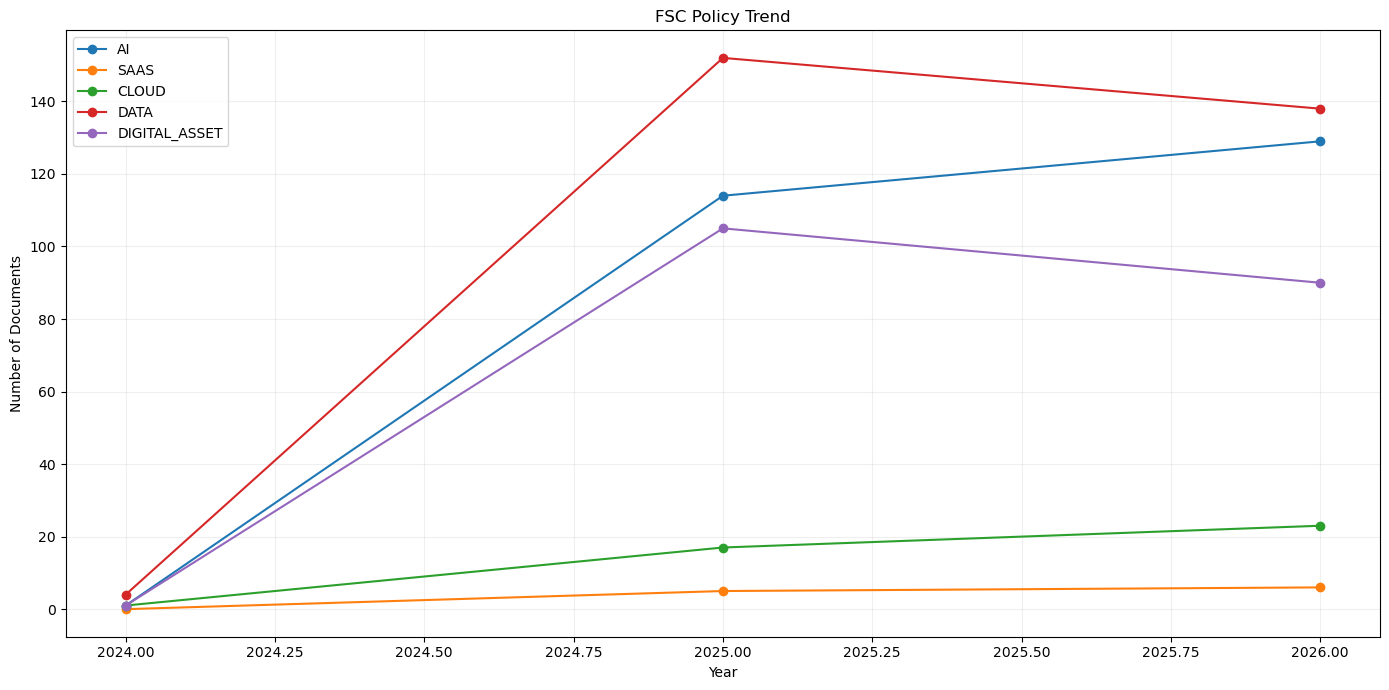

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for col in policy_cols:
    plt.plot(
        policy_year.index,
        policy_year[col],
        marker="o",
        label=col
    )

plt.title("FSC Policy Trend")
plt.xlabel("Year")
plt.ylabel("Number of Documents")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [12]:
# 03. 기술 결합 정책

df_fsc["AI_SAAS"] = (
    (df_fsc["AI"] == 1) &
    (df_fsc["SAAS"] == 1)
).astype(int)

df_fsc["AI_CLOUD"] = (
    (df_fsc["AI"] == 1) &
    (df_fsc["CLOUD"] == 1)
).astype(int)

df_fsc["AI_DATA"] = (
    (df_fsc["AI"] == 1) &
    (df_fsc["DATA"] == 1)
).astype(int)

df_fsc["AI_DIGITAL_ASSET"] = (
    (df_fsc["AI"] == 1) &
    (df_fsc["DIGITAL_ASSET"] == 1)
).astype(int)

combo_cols = [
    "AI_SAAS",
    "AI_CLOUD",
    "AI_DATA",
    "AI_DIGITAL_ASSET"
]

combo_year = (
    df_fsc
    .groupby("year")[combo_cols]
    .sum()
    .sort_index()
)

display(combo_year)

,AI_SAAS,AI_CLOUD,AI_DATA,AI_DIGITAL_ASSET
year,,,,
2024,0,1,1,1
2025,5,16,57,25
2026,5,17,69,29


In [13]:
# AI 관련 정책 최근 문서 확인

display(
    df_fsc.loc[
        df_fsc["AI"] == 1,
        ["date", "title", "url", "AI", "SAAS", "CLOUD", "DATA", "DIGITAL_ASSET"]
    ]
    .sort_values("date", ascending=False)
    .head(30)
)

,date,title,url,AI,SAAS,CLOUD,DATA,DIGITAL_ASSET
0,2026-08-25,“AI 시대 국민의 일상과 생업을 잇는 마이데이터 발전방안을 추진합니다.“,https://www.fsc.go.kr/po010101/87585?srchCtgry...,1,0,0,1,0
1,2026-08-20,"보험사기 가담자의 보험모집시장 진입을 차단하여 보험계약자 보호를 강화하고, 보험산업...",https://www.fsc.go.kr/po010101/87572?srchCtgry...,1,0,0,1,0
4,2026-08-20,"기술의 시간에 금융을 맞추는 새로운 시도, 초장기기술투자펀드가 개시됩니다.",https://www.fsc.go.kr/po010101/87569?srchCtgry...,1,0,0,0,0
6,2026-08-20,금융·통신·수사 협업으로 보이스피싱 피해 신고 전에 막는다! - 제2차 보이스피...,https://www.fsc.go.kr/po010101/87565?srchCtgry...,1,0,0,1,1
7,2026-08-19,제53차 금융중심지추진위원회 개최,https://www.fsc.go.kr/po010101/87558?srchCtgry...,1,0,0,0,0
8,2026-08-19,"“함께하는 금융, 청년의 미래를 그리다” 「2026 금융권 공동채용 박람회」 개최 ...",https://www.fsc.go.kr/po010101/87554?srchCtgry...,1,0,0,0,0
12,2026-08-12,2026년 하반기 디(D)-테스트베드 참여자 모집,https://www.fsc.go.kr/po010101/87513?srchCtgry...,1,0,0,1,0
16,2026-08-11,“국민참여성장펀드의 청년 가입기회를 확대할 계획입니다.” - 연합뉴스 8.10일자 ...,https://www.fsc.go.kr/po010101/87503?srchCtgry...,1,0,0,0,1
20,2026-08-10,"“시청 김주무관인데요, 무전기를 도매가로 대리구매 해주시면 차액을 챙겨드리겠습니다....",https://www.fsc.go.kr/po010101/87493?srchCtgry...,1,0,0,0,0
21,2026-08-04,"보이스피싱 의심 금융·통신·수사정보, ｢ASAP에이샙*｣ 통해 본격적으로 공유됩니...",https://www.fsc.go.kr/po010101/87474?srchCtgry...,1,0,0,1,1


In [14]:
# 04. Sandbox에서 발견한 기술축 관련 FSC 문서 추출

tech_cols = ["AI", "SAAS", "CLOUD"]

df_policy = df_fsc[
    df_fsc[tech_cols].sum(axis=1) > 0
].copy()

print("전체 FSC 문서:", len(df_fsc))
print("AI/SaaS/Cloud 관련:", len(df_policy))

display(
    df_policy[
        ["date", "title", "AI", "SAAS", "CLOUD"]
    ].sort_values("date", ascending=False).head(20)
)

전체 FSC 문서: 1000
AI/SaaS/Cloud 관련: 252


,date,title,AI,SAAS,CLOUD
0,2026-08-25,“AI 시대 국민의 일상과 생업을 잇는 마이데이터 발전방안을 추진합니다.“,1,0,0
6,2026-08-20,금융·통신·수사 협업으로 보이스피싱 피해 신고 전에 막는다! - 제2차 보이스피...,1,0,0
1,2026-08-20,"보험사기 가담자의 보험모집시장 진입을 차단하여 보험계약자 보호를 강화하고, 보험산업...",1,0,0
4,2026-08-20,"기술의 시간에 금융을 맞추는 새로운 시도, 초장기기술투자펀드가 개시됩니다.",1,0,0
7,2026-08-19,제53차 금융중심지추진위원회 개최,1,0,0
8,2026-08-19,"“함께하는 금융, 청년의 미래를 그리다” 「2026 금융권 공동채용 박람회」 개최 ...",1,0,0
10,2026-08-13,"가상자산사업자 신고제 강화에 맞춰 신고매뉴얼을 전면 개정합니다. - FIU·금감원,...",0,0,1
12,2026-08-12,2026년 하반기 디(D)-테스트베드 참여자 모집,1,0,0
16,2026-08-11,“국민참여성장펀드의 청년 가입기회를 확대할 계획입니다.” - 연합뉴스 8.10일자 ...,1,0,0
20,2026-08-10,"“시청 김주무관인데요, 무전기를 도매가로 대리구매 해주시면 차액을 챙겨드리겠습니다....",1,0,0


In [17]:
# ============================================================
# 금융위원회 정책 맥락 Multi-label — 한글 태그
# ============================================================

context_patterns = {

    "혁신·활성화": (
        r"활성화|육성|촉진|혁신|경쟁력|"
        r"디지털\s*전환|금융혁신"
    ),

    "도입·활용": (
        r"도입|활용|이용|적용|업무\s*활용|"
        r"서비스\s*활용|금융회사.*활용"
    ),

    "실증·특례": (
        r"샌드박스|혁신금융서비스|규제\s*특례|"
        r"실증|특례\s*지정"
    ),

    "보안·통제": (
        r"보안|정보보호|망분리|내부망|외부망|"
        r"접근통제|보호조치|보안대책|"
        r"위험관리|리스크\s*관리"
    ),

    "데이터·정보보호": (
        r"개인정보|개인신용정보|신용정보|"
        r"가명정보|가명처리|익명정보|익명처리|"
        r"데이터\s*결합|데이터\s*보호|"
        r"데이터\s*관리|데이터\s*활용"
    ),

    "규제·제도개선": (
        r"규제\s*개선|규제개선|규제\s*완화|규제완화|"
        r"제도\s*개선|제도개선|규정\s*개정|"
        r"감독규정.*개정|규제\s*혁신"
    ),

    "제도화·상시화": (
        r"제도화|상시화|상시\s*허용|정식\s*허용|"
        r"법제화|법령\s*개정|정규\s*제도|상시\s*제도"
    )
}


# 태그 생성
for label, pattern in context_patterns.items():
    df_policy[label] = (
        df_policy["analysis_text"]
        .str.contains(pattern, case=False, regex=True, na=False)
        .astype(int)
    )

context_cols = list(context_patterns.keys())


# 전체 태그 결과
print("=== 정책 맥락별 문서 수 ===")

display(
    df_policy[context_cols]
    .sum()
    .sort_values(ascending=False)
    .to_frame("문서수")
)

=== 정책 맥락별 문서 수 ===


,문서수
도입·활용,214
혁신·활성화,200
규제·제도개선,110
보안·통제,94
데이터·정보보호,63
실증·특례,55
제도화·상시화,40


In [18]:
# 연도 × 정책 맥락
context_year = (
    df_policy
    .groupby("year")[context_cols]
    .sum()
    .sort_index()
)

# 연도별 AI/SaaS/Cloud 관련 전체 문서 수
year_total = df_policy.groupby("year").size()

# 비율
context_year_ratio = (
    context_year
    .div(year_total, axis=0)
    .mul(100)
    .round(1)
)

print("=== 연도별 정책 맥락 문서 수 ===")
display(context_year)

print("=== 연도별 정책 맥락 비율(%) ===")
display(context_year_ratio)

=== 연도별 정책 맥락 문서 수 ===


,혁신·활성화,도입·활용,실증·특례,보안·통제,데이터·정보보호,규제·제도개선,제도화·상시화
year,,,,,,,
2024,1,1,0,1,1,1,0
2025,90,96,28,42,28,57,21
2026,109,117,27,51,34,52,19


=== 연도별 정책 맥락 비율(%) ===


,혁신·활성화,도입·활용,실증·특례,보안·통제,데이터·정보보호,규제·제도개선,제도화·상시화
year,,,,,,,
2024,100.0,100.0,0.0,100.0,100.0,100.0,0.0
2025,78.3,83.5,24.3,36.5,24.3,49.6,18.3
2026,80.1,86.0,19.9,37.5,25.0,38.2,14.0


In [19]:
import re

import pandas as pd

tech_pattern = re.compile(
    r"\bAI\b|인공지능|생성형\s*AI|"
    r"\bSaaS\b|서비스형\s*소프트웨어|"
    r"클라우드|\bcloud\b|망분리|내부망",
    re.I
)

def extract_tech_context(text):
    if pd.isna(text):
        return ""

    # 문장 분리
    sentences = re.split(r'(?<=[.!?다요])\s+|\n+', str(text))
    sentences = [s.strip() for s in sentences if s.strip()]

    selected = []

    for i, sentence in enumerate(sentences):
        if tech_pattern.search(sentence):

            start = max(0, i - 1)
            end = min(len(sentences), i + 2)

            selected.extend(sentences[start:end])

    # 중복 제거
    return " ".join(dict.fromkeys(selected))


df_policy["기술문맥"] = df_policy["content"].apply(extract_tech_context)

df_policy["기술문맥길이"] = df_policy["기술문맥"].str.len()

display(
    df_policy[
        ["date", "title", "AI", "SAAS", "CLOUD", "기술문맥"]
    ]
    .sort_values("date", ascending=False)
    .head(20)
)

,date,title,AI,SAAS,CLOUD,기술문맥
0,2026-08-25,“AI 시대 국민의 일상과 생업을 잇는 마이데이터 발전방안을 추진합니다.“,1,0,0,홈으로 정책마당 정책일반 금융정책 금융정책 공유하기 FaceBook X (구)트위터...
6,2026-08-20,금융·통신·수사 협업으로 보이스피싱 피해 신고 전에 막는다! - 제2차 보이스피...,1,0,0,시중은행 담당자 등과 함께 우리은행 본점에서 제2차 보이스피싱 근절 협의회 를 개최...
1,2026-08-20,"보험사기 가담자의 보험모집시장 진입을 차단하여 보험계약자 보호를 강화하고, 보험산업...",1,0,0,첨부파일 (2) 첨부파일 목록 260820(보도참고) 보험사기 가담자의 보험모집시장...
4,2026-08-20,"기술의 시간에 금융을 맞추는 새로운 시도, 초장기기술투자펀드가 개시됩니다.",1,0,0,구체적으로는 ① 기술신용 평가(TCB)에 따른 투자용 기술평가등급이 상위 5등급(T...
7,2026-08-19,제53차 금융중심지추진위원회 개최,1,0,0,". ① (금융산업 혁신 제고) 인구구조 변화, AI 및 디지털 기술 발전 등 시대 ..."
8,2026-08-19,"“함께하는 금융, 청년의 미래를 그리다” 「2026 금융권 공동채용 박람회」 개최 ...",1,0,0,< 2026 금융권 공동채용 박람회 개요 > ▪ ( 일시 ) ’26.8.19.(수)...
10,2026-08-13,"가상자산사업자 신고제 강화에 맞춰 신고매뉴얼을 전면 개정합니다. - FIU·금감원,...",0,0,1,③ 조직·인력 요건에서는 자금세탁방지 업무 종사 인력(4인 이상) 의 규모 와 함께...
12,2026-08-12,2026년 하반기 디(D)-테스트베드 참여자 모집,1,0,0,"이번 2026년 하반기 D-테스트베드 참여 부문 으로는 협업과제형, 공익 과 제형,..."
16,2026-08-11,“국민참여성장펀드의 청년 가입기회를 확대할 계획입니다.” - 연합뉴스 8.10일자 ...,1,0,0,2. 동 보도내용에 대한 설명 (1) 국민참여성장펀드 조성 취지 및 상품 특성 □ ...
20,2026-08-10,"“시청 김주무관인데요, 무전기를 도매가로 대리구매 해주시면 차액을 챙겨드리겠습니다....",1,0,0,"첨부파일 (2) 첨부파일 목록 260810 공무원의 달콤한 대리구매 유혹, 100%..."


In [22]:
# AI / SaaS / Cloud × 연도별 정책 워딩 변화

import re

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. 기술별 키워드
tech_patterns = {
    "AI": r"\bAI\b|인공지능|생성형\s*AI|생성형AI|LLM|머신러닝|딥러닝",
    
    "SaaS": r"\bSaaS\b|서비스형\s*소프트웨어|Software\s*as\s*a\s*Service",
    
    "Cloud": r"클라우드|\bCloud\b|망분리|내부망"
}


# 2. 해당 기술이 직접 등장한 문장만 추출

def extract_sentences(text, pattern):
    if pd.isna(text):
        return ""

    text = str(text)

    # 사이트 노이즈 제거
    noise = [
        "파일다운로드",
        "파일뷰어",
        "첨부파일",
        "보도자료"
    ]

    for word in noise:
        text = text.replace(word, " ")

    # 문장 분리
    sentences = re.split(r"[.!?]\s*|\n+", text)

    matched = [
        s.strip()
        for s in sentences
        if re.search(pattern, s, flags=re.I)
    ]

    return " ".join(matched)


for tech, pattern in tech_patterns.items():
    df_fsc[f"{tech}_문맥"] = df_fsc["content"].apply(
        lambda x, pattern=pattern: extract_sentences(x, pattern)
    )

In [23]:
for tech in tech_patterns:

    col = f"{tech}_문맥"

    print(f"\n===== {tech} =====")

    print(
        df_fsc.loc[
            df_fsc[col].str.len() > 0
        ]
        .groupby("year")
        .size()
    )


===== AI =====
year
2025    112
2026    128
dtype: int64

===== SaaS =====
year
2025    5
2026    6
dtype: int64

===== Cloud =====
year
2024     1
2025    17
2026    23
dtype: int64


In [24]:
stopwords = [
    # 일반 조사/서술
    "금융", "금융위원회", "위원회",
    "대한", "위한", "위해", "통해",
    "관련", "등을", "으로", "있는",
    "있다", "하여", "하였다", "하고",
    "하는", "있도록", "및",

    # 홈페이지 노이즈
    "파일다운로드", "파일뷰어",
    "첨부파일", "보도자료",

    # 금액/단위 노이즈
    "억원", "조원", "kb"
]

In [25]:
def get_keywords(df, tech, year, top_n=20):

    col = f"{tech}_문맥"

    texts = df.loc[
        (df["year"] == year) &
        (df[col].str.len() > 0),
        col
    ].dropna()

    if len(texts) < 2:
        print(f"{tech} {year}: 문서 부족 ({len(texts)}건)")
        return None

    vectorizer = TfidfVectorizer(
        token_pattern=r"(?u)\b[가-힣A-Za-z]{2,}\b",
        ngram_range=(1, 2),
        min_df=2,
        stop_words=stopwords
    )

    try:
        X = vectorizer.fit_transform(texts)
    except ValueError:
        return None

    scores = X.mean(axis=0).A1
    terms = vectorizer.get_feature_names_out()

    result = pd.DataFrame({
        "워딩": terms,
        "TFIDF": scores
    })

    return (
        result
        .sort_values("TFIDF", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

In [26]:
for tech in ["AI", "SaaS", "Cloud"]:

    print("\n")
    print("=" * 60)
    print(f" {tech} 정책 워딩 변화")
    print("=" * 60)

    for year in sorted(df_fsc["year"].dropna().unique()):

        print(f"\n[{int(year)}]")

        result = get_keywords(
            df_fsc,
            tech,
            year,
            top_n=20
        )

        if result is not None:
            display(result)



 AI 정책 워딩 변화

[2024]
AI 2024: 문서 부족 (0건)

[2025]


,워딩,TFIDF
0,ai,0.083343
1,핀테크,0.041463
2,보이스피싱,0.032364
3,지원,0.026115
4,플랫폼,0.023302
5,강화,0.020984
6,서비스,0.020950
7,인공지능,0.020199
8,분야,0.019973
9,데이터,0.019712



[2026]


,워딩,TFIDF
0,ai,0.097180
1,반도체,0.033446
2,지원,0.029647
3,보이스피싱,0.026117
4,인프라,0.025681
5,ai 반도체,0.022289
6,글로벌,0.019984
7,다음글,0.018767
8,활용,0.018010
9,강화,0.017859




 SaaS 정책 워딩 변화

[2024]
SaaS 2024: 문서 부족 (0건)

[2025]


...

,워딩,TFIDF
0,saas,0.231734
1,서비스,0.183679
2,망분리,0.154324
3,내부,0.139273
4,활용,0.115227
5,클라우드,0.110082
6,보다,0.108100
7,기반,0.107660
8,대상,0.103657
9,응용소프트웨어,0.102569




 Cloud 정책 워딩 변화

[2024]
Cloud 2024: 문서 부족 (1건)

[2025]


,워딩,TFIDF
0,클라우드,0.088221
1,서비스,0.087999
2,ai,0.086317
3,데이터,0.068383
4,지정,0.067008
5,망분리,0.065102
6,혁신금융서비스,0.062523
7,이용,0.060624
8,활용한,0.058359
9,지난,0.055987



[2026]


,워딩,TFIDF
0,ai,0.150644
1,망분리,0.110853
2,규제,0.077425
3,클라우드,0.071662
4,망분리 규제,0.061965
5,서비스,0.047711
6,금융권,0.047155
7,클라우드 기반,0.044749
8,기반,0.043906
9,규제를,0.041981


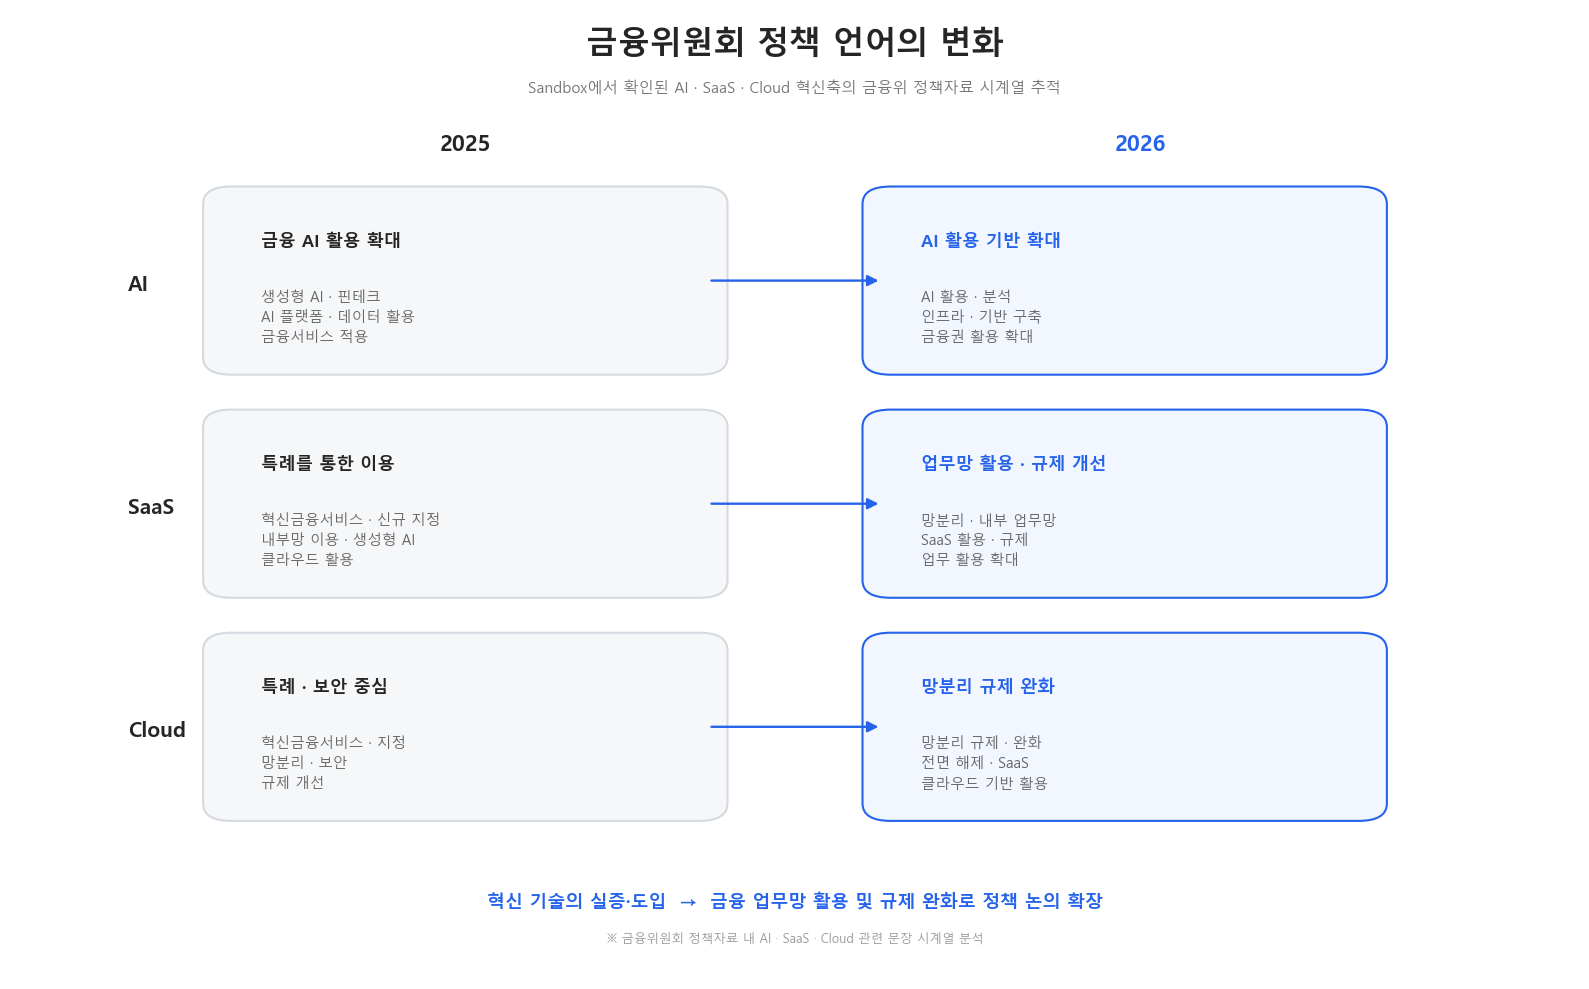

In [28]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor("white")
ax.axis("off")

BLUE = "#2563EB"
TEXT = "#252525"
GRAY = "#666666"
LIGHT = "#F6F7F9"
LIGHT_BLUE = "#F2F6FF"
BORDER = "#D5D9E0"

# 제목

ax.text(
    0.5, 0.955,
    "금융위원회 정책 언어의 변화",
    ha="center",
    fontsize=23,
    fontweight="bold",
    color=TEXT,
    transform=ax.transAxes
)

ax.text(
    0.5, 0.915,
    "Sandbox에서 확인된 AI · SaaS · Cloud 혁신축의 금융위 정책자료 시계열 추적",
    ha="center",
    fontsize=11,
    color="#777777",
    transform=ax.transAxes
)

# 연도
ax.text(
    0.29, 0.855, "2025",
    ha="center",
    fontsize=16,
    fontweight="bold",
    color=TEXT,
    transform=ax.transAxes
)

ax.text(
    0.72, 0.855, "2026",
    ha="center",
    fontsize=16,
    fontweight="bold",
    color=BLUE,
    transform=ax.transAxes
)

 
# 박스 함수

def draw_box(x, y, title, lines, highlight=False):

    w = 0.31
    h = 0.17

    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.012,rounding_size=0.018",
        linewidth=1.5,
        edgecolor=BLUE if highlight else BORDER,
        facecolor=LIGHT_BLUE if highlight else LIGHT,
        transform=ax.transAxes
    )

    ax.add_patch(patch)

    # 제목
    ax.text(
        x + 0.025,
        y + h - 0.045,
        title,
        fontsize=12.5,
        fontweight="bold",
        color=BLUE if highlight else TEXT,
        va="center",
        transform=ax.transAxes
    )

    # 내용
    ax.text(
        x + 0.025,
        y + h - 0.095,
        "\n".join(lines),
        fontsize=10.5,
        color=GRAY,
        va="top",
        linespacing=1.45,
        transform=ax.transAxes
    )


def draw_arrow(y):

    arrow = FancyArrowPatch(
        (0.445, y),
        (0.555, y),
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.7,
        color=BLUE,
        transform=ax.transAxes
    )

    ax.add_patch(arrow)


# ============================================================
# AI
# ============================================================

y1 = 0.635

ax.text(
    0.075, y1 + 0.075,
    "AI",
    fontsize=15,
    fontweight="bold",
    color=TEXT,
    transform=ax.transAxes
)

draw_box(
    0.135, y1,
    "금융 AI 활용 확대",
    [
        "생성형 AI · 핀테크",
        "AI 플랫폼 · 데이터 활용",
        "금융서비스 적용"
    ]
)

draw_box(
    0.555, y1,
    "AI 활용 기반 확대",
    [
        "AI 활용 · 분석",
        "인프라 · 기반 구축",
        "금융권 활용 확대"
    ],
    highlight=True
)

draw_arrow(y1 + 0.085)


# ============================================================
# SaaS
# ============================================================

y2 = 0.405

ax.text(
    0.075, y2 + 0.075,
    "SaaS",
    fontsize=15,
    fontweight="bold",
    color=TEXT,
    transform=ax.transAxes
)

draw_box(
    0.135, y2,
    "특례를 통한 이용",
    [
        "혁신금융서비스 · 신규 지정",
        "내부망 이용 · 생성형 AI",
        "클라우드 활용"
    ]
)

draw_box(
    0.555, y2,
    "업무망 활용 · 규제 개선",
    [
        "망분리 · 내부 업무망",
        "SaaS 활용 · 규제",
        "업무 활용 확대"
    ],
    highlight=True
)

draw_arrow(y2 + 0.085)


# CLOUD

y3 = 0.175

ax.text(
    0.075, y3 + 0.075,
    "Cloud",
    fontsize=15,
    fontweight="bold",
    color=TEXT,
    transform=ax.transAxes
)

draw_box(
    0.135, y3,
    "특례 · 보안 중심",
    [
        "혁신금융서비스 · 지정",
        "망분리 · 보안",
        "규제 개선"
    ]
)

draw_box(
    0.555, y3,
    "망분리 규제 완화",
    [
        "망분리 규제 · 완화",
        "전면 해제 · SaaS",
        "클라우드 기반 활용"
    ],
    highlight=True
)

draw_arrow(y3 + 0.085)


# 결론

ax.text(
    0.5, 0.075,
    "혁신 기술의 실증·도입  →  금융 업무망 활용 및 규제 완화로 정책 논의 확장",
    ha="center",
    fontsize=13,
    fontweight="bold",
    color=BLUE,
    transform=ax.transAxes
)

ax.text(
    0.5, 0.038,
    "※ 금융위원회 정책자료 내 AI · SaaS · Cloud 관련 문장 시계열 분석",
    ha="center",
    fontsize=9,
    color="#999999",
    transform=ax.transAxes
)

plt.tight_layout()

plt.savefig(
    "fsc_policy_shift_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()